In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE = "/content/drive/MyDrive/Aadhaar_Data"

EXPLORATORY DATA ANALYSIS USING CLEANED DATASETS

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Load Datasets
enrol = pd.read_csv("/content/drive/MyDrive/Aadhaar_Data/enrolment_clean.csv",parse_dates = ['date'] )
demo = pd.read_csv("/content/drive/MyDrive/Aadhaar_Data/demographic_clean.csv", parse_dates= ['date'])
bio = pd.read_csv("/content/drive/MyDrive/Aadhaar_Data/biometric_clean.csv", parse_dates= ['date'])

In [ ]:
enrol['total_enrolment'] = enrol[['age_0_5','age_5_17','age_18_greater']].sum(axis=1)
demo['total_demo_updates'] = demo[['demo_age_5_17','demo_age_17_']].sum(axis=1)
bio['total_bio_updates'] = bio[['bio_age_5_17','bio_age_17_']].sum(axis=1)

In [ ]:
enrol.columns

Index(['state', 'district', 'date', 'age_0_5', 'age_5_17', 'age_18_greater',
       'total_enrolment'],
      dtype='object')

In [ ]:
enrol.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66749 entries, 0 to 66748
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   state           66749 non-null  object        
 1   district        66749 non-null  object        
 2   date            66749 non-null  datetime64[ns]
 3   age_0_5         66749 non-null  int64         
 4   age_5_17        66749 non-null  int64         
 5   age_18_greater  66749 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 3.1+ MB


In [ ]:
demo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86125 entries, 0 to 86124
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   state          86125 non-null  object        
 1   district       86125 non-null  object        
 2   date           86125 non-null  datetime64[ns]
 3   demo_age_5_17  86125 non-null  int64         
 4   demo_age_17_   86125 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 3.3+ MB


In [ ]:
bio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79794 entries, 0 to 79793
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   state         79794 non-null  object        
 1   district      79794 non-null  object        
 2   date          79794 non-null  datetime64[ns]
 3   bio_age_5_17  79794 non-null  int64         
 4   bio_age_17_   79794 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 3.0+ MB


In [ ]:
enrol.describe()

,date,age_0_5,age_5_17,age_18_greater
count,66749,66749.000000,66749.000000,66749.000000
mean,2025-10-04 10:19:08.026187520,53.138849,25.773929,2.522180
min,2025-03-01 00:00:00,0.000000,0.000000,0.000000
25%,2025-09-01 00:00:00,6.000000,1.000000,0.000000
50%,2025-10-01 00:00:00,24.000000,5.000000,0.000000
75%,2025-11-01 00:00:00,62.000000,20.000000,0.000000
max,2025-12-01 00:00:00,6740.000000,6314.000000,2404.000000
std,NaN,135.836947,118.131864,27.573139


In [ ]:
demo.describe()

,date,demo_age_5_17,demo_age_17_
count,86125,86125.000000,86125.000000
mean,2025-10-17 12:24:01.086792704,56.469364,515.898554
min,2025-03-01 00:00:00,0.000000,0.000000
25%,2025-10-01 00:00:00,3.000000,34.000000
50%,2025-11-01 00:00:00,18.000000,155.000000
75%,2025-12-01 00:00:00,50.000000,432.000000
max,2025-12-01 00:00:00,9362.000000,74631.000000
std,NaN,222.467714,2077.397164


In [ ]:
bio.describe()

,date,bio_age_5_17,bio_age_17_
count,79794,79794.000000,79794.000000
mean,2025-10-10 05:42:16.160613632,428.940209,445.349776
min,2025-03-01 00:00:00,0.000000,0.000000
25%,2025-09-01 00:00:00,12.000000,16.000000
50%,2025-11-01 00:00:00,95.000000,96.000000
75%,2025-12-01 00:00:00,278.000000,275.000000
max,2025-12-01 00:00:00,56618.000000,51939.000000
std,NaN,1621.052453,1765.932210


In [ ]:
enrol.shape

(66749, 6)

In [ ]:
demo.shape

(86125, 5)

In [ ]:
bio.shape

(79794, 5)

In [ ]:
#Remove numeric locations
def remove_numeric_locations(df):
    df = df[~df['state'].str.isnumeric()]
    df = df[~df['district'].str.isnumeric()]
    return df

enrol = remove_numeric_locations(enrol)
demo = remove_numeric_locations(demo)
bio = remove_numeric_locations(bio)

In [ ]:
#Normalize Text
def normalize_text(df):
    df['state'] = df['state'].str.lower().str.strip()
    df['district'] = df['district'].str.lower().str.strip()
    return df

enrol = normalize_text(enrol)
demo = normalize_text(demo)
bio = normalize_text(bio)

In [ ]:
def hard_normalize_state(df):
    df['state'] = (
        df['state']
        .str.lower()
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)   # remove double spaces
        .str.replace('\u00a0', ' ', regex=True) # remove non-breaking space
    )
    return df

enrol = hard_normalize_state(enrol)
demo = hard_normalize_state(demo)
bio = hard_normalize_state(bio)

In [ ]:
def remove_the_prefix(df):
    df['state'] = df['state'].str.replace(r'^the\s+', '', regex=True)
    return df

enrol = remove_the_prefix(enrol)
demo = remove_the_prefix(demo)
bio = remove_the_prefix(bio)

In [ ]:
invalid_states = [
    'balanagar','darbhanga','jaipur','madanapalle',
    'nagpur','puttenahalli','raja annamalai puram'
]

def remove_city_noise(df):
    df = df[~df['state'].isin(invalid_states)]
    return df

enrol = remove_city_noise(enrol)
demo = remove_city_noise(demo)
bio = remove_city_noise(bio)

In [ ]:
state_fix_map = {

    # Andaman & Nicobar
    "andaman & nicobar islands": "andaman and nicobar islands",

    # Dadra Nagar Haveli + Daman Diu (merged UT)
    "dadra & nagar haveli": "dadra and nagar haveli and daman and diu",
    "dadra and nagar haveli": "dadra and nagar haveli and daman and diu",
    "dadra and nagar haveli and daman and diu": "dadra and nagar haveli and daman and diu",
    "daman and diu": "dadra and nagar haveli and daman and diu",
    "daman & diu": "dadra and nagar haveli and daman and diu",

    # Jammu & Kashmir
    "jammu & kashmir": "jammu and kashmir",

    # West Bengal variants
    "westbengal": "west bengal",
    "west  bengal": "west bengal",
    "west bangal": "west bengal",
    "west bengli": "west bengal",

    # Odisha
    "orissa": "odisha",

    # Puducherry
    "pondicherry": "puducherry",

    # Chhattisgarh
    "chhatisgarh": "chhattisgarh",

    # Tamil Nadu
    "tamilnadu": "tamil nadu",

    # Uttarakhand
    "uttaranchal": "uttarakhand"
}

In [ ]:
enrol['state'] = enrol['state'].replace(state_fix_map)
demo['state'] = demo['state'].replace(state_fix_map)
bio['state'] = bio['state'].replace(state_fix_map)

In [ ]:
demo['state'].nunique()
bio['state'].nunique()
enrol['state'].nunique()

36

In [ ]:
enrol.to_csv("enrolment_final.csv", index=False)
demo.to_csv("demographic_final.csv", index=False)
bio.to_csv("biometric_final.csv", index=False)

UNIVARIATE ANALYSIS

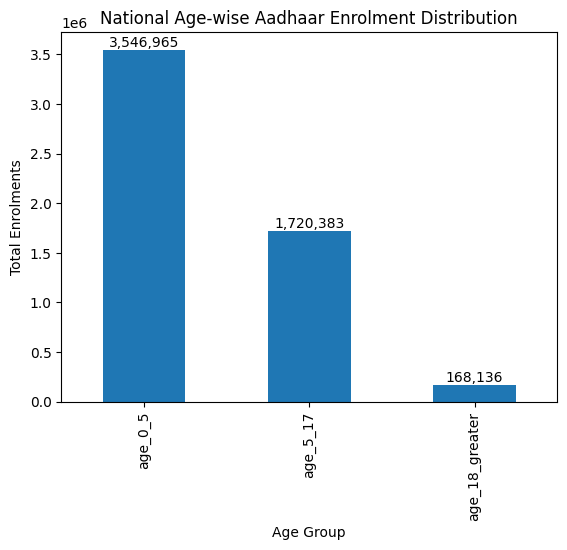

In [ ]:
#National Age-wise Enrolment Distribution
ax = enrol[['age_0_5','age_5_17','age_18_greater']].sum().plot(kind='bar')

plt.title("National Age-wise Aadhaar Enrolment Distribution")
plt.ylabel("Total Enrolments")
plt.xlabel("Age Group")

# Add value labels
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.show()

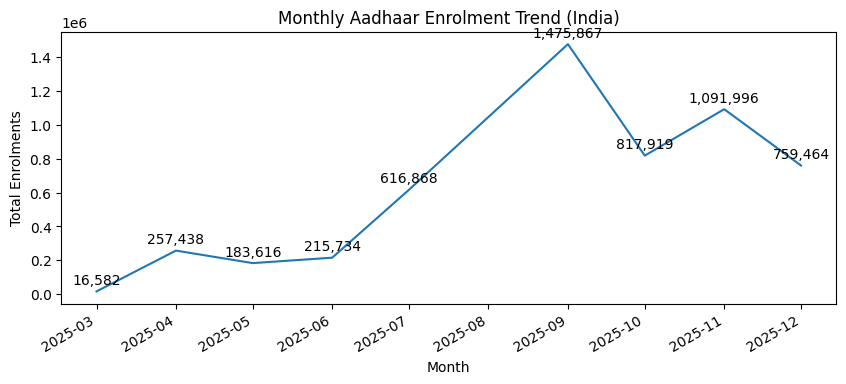

In [ ]:
#Monthly Enrolment Trend
monthly = enrol.groupby('date')['total_enrolment'].sum()

ax = monthly.plot(figsize=(10,4))

plt.title("Monthly Aadhaar Enrolment Trend (India)")
plt.ylabel("Total Enrolments")
plt.xlabel("Month")

# Add data points
for x, y in zip(monthly.index, monthly.values):
    ax.annotate(f'{int(y):,}', (x, y), textcoords="offset points", xytext=(0,5), ha='center')

plt.show()

In [ ]:
#Top states by enrolment
enrol.groupby('state')['total_enrolment'].sum().sort_values(ascending=False).head(15)

,total_enrolment
state,
uttar pradesh,1018629
bihar,609585
madhya pradesh,493970
west bengal,375340
maharashtra,369139
rajasthan,348458
gujarat,280549
assam,230197
karnataka,223235


BIVARIATE ANALYSIS

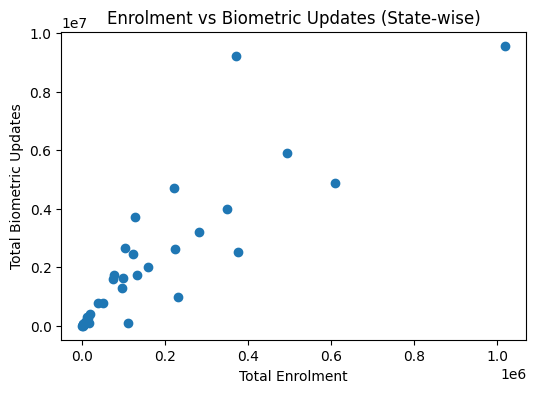

,total_enrolment,total_bio_updates
total_enrolment,1.000000,0.869615
total_bio_updates,0.869615,1.000000


In [ ]:
#Enrolment vs Biometric Updates (State-wise)

state_enrol = enrol.groupby('state')['total_enrolment'].sum().reset_index()
state_bio = bio.groupby('state')['total_bio_updates'].sum().reset_index()

enrol_bio = pd.merge(state_enrol, state_bio, on='state')

# Scatter plot
plt.figure(figsize=(6,4))
plt.scatter(enrol_bio['total_enrolment'], enrol_bio['total_bio_updates'])
plt.xlabel("Total Enrolment")
plt.ylabel("Total Biometric Updates")
plt.title("Enrolment vs Biometric Updates (State-wise)")
plt.show()

# Correlation
enrol_bio[['total_enrolment','total_bio_updates']].corr()


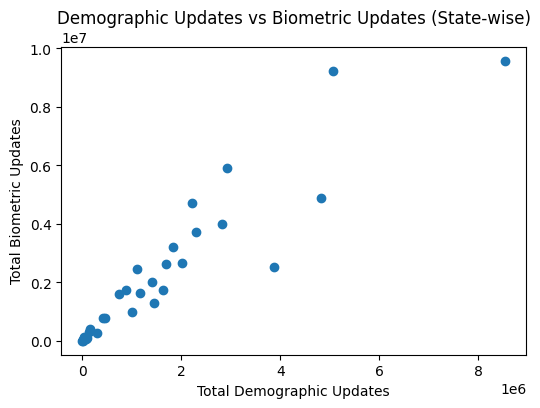

,total_demo_updates,total_bio_updates
total_demo_updates,1.000000,0.930125
total_bio_updates,0.930125,1.000000


In [ ]:
#Demographic Updates vs Biometric Updates (State-wise)

state_demo = demo.groupby('state')['total_demo_updates'].sum().reset_index()

demo_bio = pd.merge(state_demo, state_bio, on='state')

# Scatter plot
plt.figure(figsize=(6,4))
plt.scatter(demo_bio['total_demo_updates'], demo_bio['total_bio_updates'])
plt.xlabel("Total Demographic Updates")
plt.ylabel("Total Biometric Updates")
plt.title("Demographic Updates vs Biometric Updates (State-wise)")
plt.show()

# Correlation
demo_bio[['total_demo_updates','total_bio_updates']].corr()

In [ ]:
enrol_bio.to_csv("state_enrolment_vs_biometric.csv", index=False)
demo_bio.to_csv("state_demographic_vs_biometric.csv", index=False)

TRIVARIATE ANALYSIS

In [ ]:
#state month aggregation
state_month = enrol.groupby(['state','date'])['total_enrolment'].sum().reset_index()
state_month.head()

,state,date,total_enrolment
0,andaman and nicobar islands,2025-09-01,188
1,andaman and nicobar islands,2025-10-01,82
2,andaman and nicobar islands,2025-11-01,112
3,andaman and nicobar islands,2025-12-01,129
4,andhra pradesh,2025-03-01,116


In [ ]:
#Top States by Enrolment
top_states = enrol.groupby('state')['total_enrolment'].sum() \
                  .sort_values(ascending=False) \
                  .head(15).index

top_state_trends = state_month[state_month['state'].isin(top_states)]

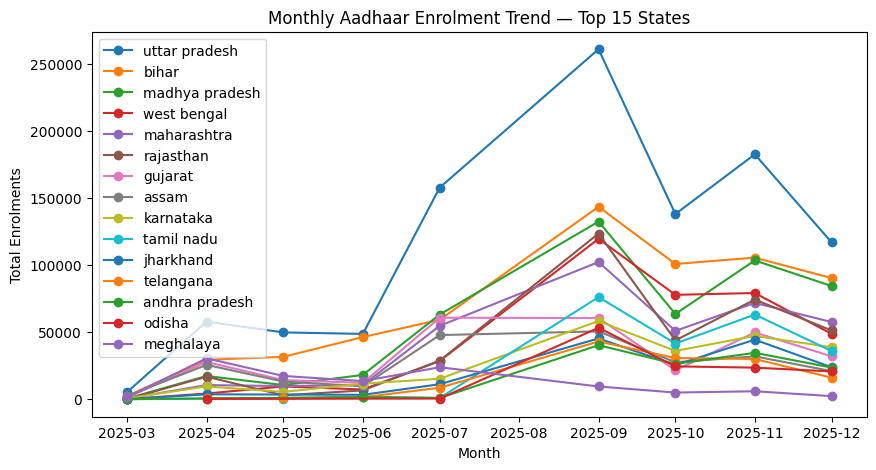

In [ ]:
#Trivariate trend
plt.figure(figsize=(10,5))

for s in top_states:
    data = top_state_trends[top_state_trends['state'] == s]
    plt.plot(data['date'], data['total_enrolment'], marker='o', label=s)

plt.legend()
plt.title("Monthly Aadhaar Enrolment Trend — Top 15 States")
plt.xlabel("Month")
plt.ylabel("Total Enrolments")
plt.show()

In [ ]:
top_state_trends.to_csv("state_month_trends.csv", index=False)

ANOMALY DETECTION

In [ ]:
#District aggregation
district_bio = bio.groupby('district')['total_bio_updates'].sum()

In [ ]:
#Z-score based anomaly detection
mean_val = district_bio.mean()
std_val = district_bio.std()

z_scores = (district_bio - mean_val) / std_val

anomaly_table = pd.DataFrame({
    'district': district_bio.index,
    'total_bio_updates': district_bio.values,
    'z_score': z_scores.values
})

# Keep only extreme anomalies
anomaly_table = anomaly_table[anomaly_table['z_score'] > 3]

anomaly_table = anomaly_table.sort_values(by='total_bio_updates', ascending=False)

anomaly_table.head()

,district,total_bio_updates,z_score
690,pune,605762,6.518288
612,nashik,576606,6.161224
853,thane,571273,6.095912
362,jalgaon,417384,4.211285
49,aurangabad,407803,4.093949


In [ ]:
anomaly_table.to_csv("district_biometric_anomalies.csv")

In [ ]:
#Lifecycle pressure index
state_youth_bio = bio.groupby('state')['bio_age_5_17'].sum()
state_adult_bio = bio.groupby('state')['bio_age_17_'].sum()

youth_pressure = (state_youth_bio / (state_youth_bio + state_adult_bio)) * 100

youth_pressure = youth_pressure.dropna()

youth_pressure.sort_values(ascending=False).head(10)

,0
state,
mizoram,71.080953
chandigarh,66.017293
uttar pradesh,64.807650
assam,60.711371
andhra pradesh,60.341547
arunachal pradesh,59.250767
manipur,58.907522
andaman and nicobar islands,57.039327
uttarakhand,55.499533


In [ ]:
yp_df = youth_pressure.reset_index()
yp_df.columns = ['state','youth_biometric_pressure_percent']

yp_df.to_csv("state_youth_pressure.csv", index=False)